In [1]:
import requests
import pandas as pd
from tqdm import tqdm

In [2]:
LAT = -1.1714
LON = 36.8356

In [3]:
START = "20160101"
END = "20251231"

In [4]:
parameters = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "RH2M",
    "PRECTOTCORR",
    "WS2M",
    "ALLSKY_SFC_SW_DWN"
]

In [5]:
parameter_string = ",".join(parameters)

url = (
    "https://power.larc.nasa.gov/api/temporal/daily/point?"
    f"parameters={parameter_string}"
    f"&community=AG"
    f"&longitude={LON}"
    f"&latitude={LAT}"
    f"&start={START}"
    f"&end={END}"
    f"&format=JSON"
)

In [6]:
response = requests.get(url)

print(response.status_code)

200


In [7]:
data = response.json()

In [8]:
weather = data["properties"]["parameter"]

In [10]:
df = pd.DataFrame(weather)

In [11]:
df = df.T

In [18]:
df.columns = [
    "Date",
    "Temperature",
    "Max_Temperature",
    "Min_Temperature",
    "Relative_Humidity",
    "Rainfall",
    "Wind_Speed",
    "Solar_Radiation"
]

ValueError: Length mismatch: Expected axis has 8 elements, new values have 7 elements

In [17]:
df.columns = pd.to_datetime(df.columns, format='%Y%m%d')
df = df.T
df.reset_index(inplace=True)
df.rename(columns={"index": "Date"}, inplace=True)

In [19]:
print(df.head())

        Date  Temperature  Max_Temperature  Min_Temperature  \
0 2016-01-01        19.94            26.62            14.85   
1 2016-01-02        18.89            26.15            13.02   
2 2016-01-03        18.77            25.95            13.02   
3 2016-01-04        18.80            24.16            15.21   
4 2016-01-05        18.58            24.22            15.05   

   Relative_Humidity  Rainfall  Wind_Speed  Solar_Radiation  
0              72.57      0.01        2.70            26.93  
1              73.27      0.49        2.97            25.65  
2              78.50      5.70        3.29            24.74  
3              83.54     11.28        4.17            16.70  
4              82.98      7.03        4.02            24.17  


In [20]:
df.isnull().sum()

,0
Date,0
Temperature,0
Max_Temperature,0
Min_Temperature,0
Relative_Humidity,0
Rainfall,0
Wind_Speed,0
Solar_Radiation,0


In [21]:
df.describe()

,Date,Temperature,Max_Temperature,Min_Temperature,Relative_Humidity,Rainfall,Wind_Speed,Solar_Radiation
count,3653,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000
mean,2020-12-31 00:00:00,19.092321,26.053345,13.728191,70.133123,2.031818,2.716803,20.781500
min,2016-01-01 00:00:00,14.400000,18.420000,8.670000,38.670000,0.000000,0.480000,5.490000
25%,2018-07-02 00:00:00,18.180000,24.390000,12.710000,63.090000,0.120000,2.160000,17.850000
50%,2020-12-31 00:00:00,19.010000,26.070000,13.790000,70.690000,0.450000,2.730000,21.140000
75%,2023-07-02 00:00:00,20.080000,27.760000,14.810000,77.410000,1.790000,3.270000,24.180000
max,2025-12-31 00:00:00,23.760000,32.530000,17.770000,92.120000,94.720000,4.680000,29.230000
std,NaN,1.400686,2.372242,1.431654,9.719093,4.815446,0.729410,4.339984


In [22]:
df.to_csv("kiambu_weather_2016_2025.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


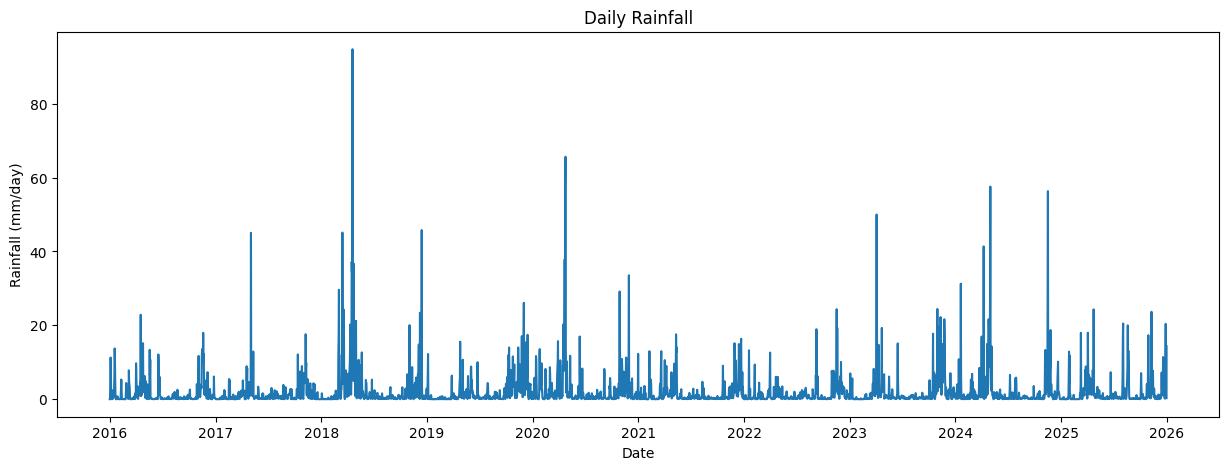

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df["Date"], df["Rainfall"])

plt.title("Daily Rainfall")

plt.xlabel("Date")

plt.ylabel("Rainfall (mm/day)")

plt.show()

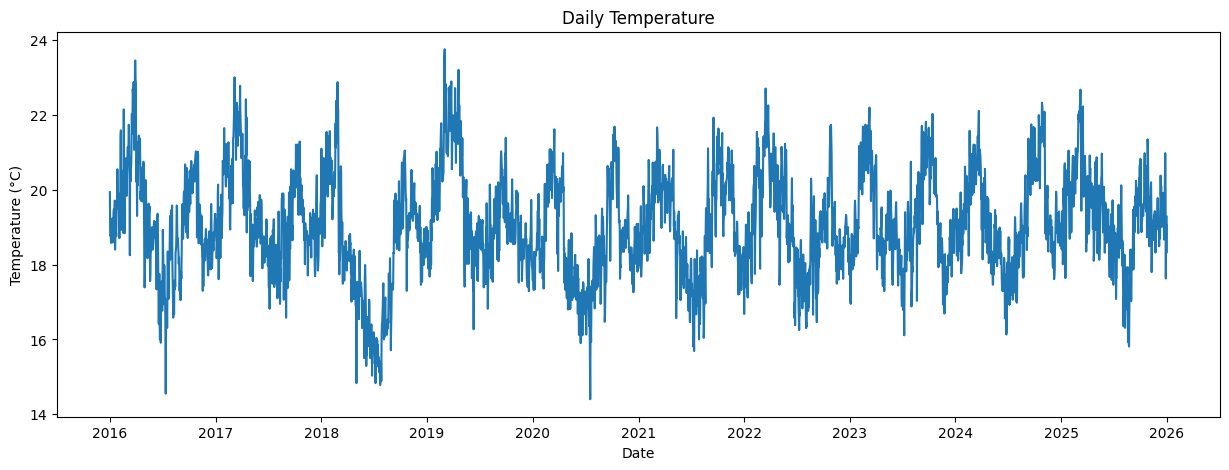

In [24]:
plt.figure(figsize=(15,5))

plt.plot(df["Date"], df["Temperature"])

plt.title("Daily Temperature")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.show()

In [25]:
from google.colab import files

files.download("kiambu_weather_2016_2025.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>